### Settings

In [8]:
from ema_forecast_control.utils import path_utils, model_catalogue

project_name = 'test_project2'
test_data_dir = path_utils.join_base_path('data/AI4U_sample2')

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']

inverted_items = [1, 2, 3, 4, 5, 7, 8, 10, 12]

initial_condition_version = 'trajectory'        # 'trajectory', 'unit vectors'

save_dir = f'AI4U/individual_networks_{project_name}'

models = model_catalogue.ModelCatalogue(project_name, force_new_catalogue=True)

alpha_level = 0.05 / (15 ** 2)

select_participants = ['12', '13']

### Network calculation

In [9]:
import torch as tc
import matplotlib.pyplot as plt

from ema_forecast_control.plrnn.plrnn_model import PLRNN
from ema_forecast_control.utils import path_utils
from ema_forecast_control.utils import network_utils
from ema_forecast_control.utils.backwards_compatibility import determine_model_class

networks = []
no_gamma_found = []

for p, df in path_utils.zip_participants_data(test_data_dir):

    if p not in select_participants:
        continue
    print(f'including participant {p}')
    model_dirs = models.get_latest_model_dirs(p, timestep=1000)
    participant_networks = []
    for model_dir in model_dirs:            
        if model_dir is None:
            continue
        args = path_utils.load_args(model_dir)
        model_class = determine_model_class(args)
        model = model_class(args)
        model.init_from_model_path(model_dir)
        if isinstance(model, PLRNN):
            if initial_condition_version == 'trajectory':
                x = tc.tensor(df[labels].to_numpy()).float()
            elif initial_condition_version == 'unit vectors':
                x = tc.cat((tc.eye(len(labels)).float(), tc.zeros(len(labels)).float().unsqueeze(0)), 0)
            try:
                Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
                network = network_utils.get_network_matrix(model, x, Gamma=Gamma).nanmean(0)
            except FileNotFoundError:
                no_gamma_found.append(p)
                network = network_utils.get_network_matrix(model, x).nanmean(0)
        else:
            network = network_utils.get_network_matrix(model)
        participant_networks.append(network)
    if len(participant_networks) > 0:
        participant_networks = tc.stack(participant_networks, dim=0).mean(0)
        networks.append(participant_networks)                    

if len(no_gamma_found) > 0:
    print(f'Found no Covariance Gamma for subjects {no_gamma_found}.')


including participant 12
including participant 13
Found no Covariance Gamma for subjects ['12', '13'].


### Network plots

Counterintuitive connections found between the following items:
  EMA_concentration* --> EMA_down*
  EMA_resilience --> EMA_down*
Counterintuitive connections found between the following items:
  EMA_mood --> EMA_lonely*
  EMA_scared* --> EMA_lonely*
  EMA_confidence --> EMA_lonely*
  EMA_energetic --> EMA_lonely*
  EMA_concentration* --> EMA_lonely*
  EMA_tired* --> EMA_worry*
  EMA_tired* --> EMA_lonely*


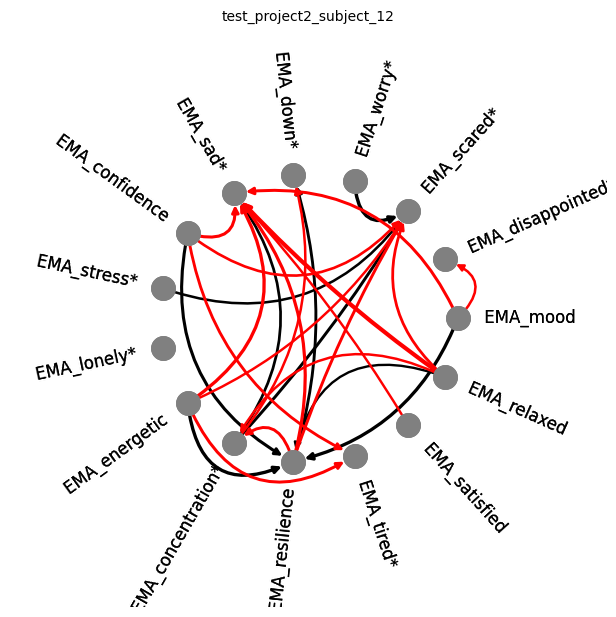

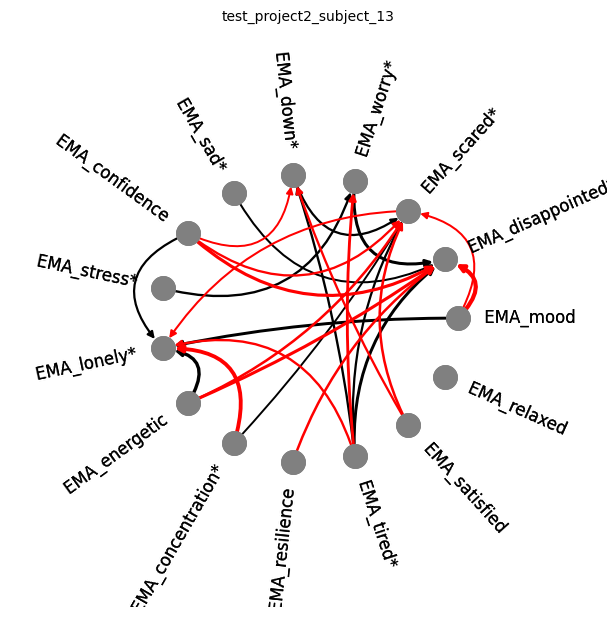

In [10]:
import os
from ema_forecast_control.plotting.plotting_styles import PaperStyle

if len(networks) > 0:
    with PaperStyle(settings={'axes.grid':False, 'axes.facecolor':'white'}):
        for p, netw in zip(select_participants, networks):
            network_utils.plot_individual_network_graph(netw, node_labels=labels, inverted_items=inverted_items, 
                                                        title=f'{project_name}_subject_{p}', max_edge_number=25)
            if save_dir is not None:
                path = path_utils.join_base_path('results', save_dir)
                os.makedirs(path, exist_ok=True)
                filename = os.path.join(path, f'{p}.png')
                plt.savefig(path, dpi=300)
        plt.show()